# KALMAN_FILTER

![kalman filter](https://it.mathworks.com/videos/understanding-kalman-filters-part-3-optimal-state-estimator--1490710645421/_jcr_content/thumbnail.adapt.1200.medium.jpg/1763309995068.jpg)

# A. Giới thiệu



## 1. Động tuyến tính

### 1.1. Định nghĩa
**Động tuyến tính có nhiễu Gaussian - Linear dynamics with Gaussian noise** là một mô hình toán học dùng để mô tả sự tiến hóa theo thời gian của một hệ tuyến tính, trong đó nhiễu (noise) được giả sử phân phối Gaussian (chuẩn). Hay nói cách khác là hệ thống tiến hóa theo thời gian, tuân theo quy luật tuyến tính, nhưng bị ảnh hưởng bởi nhiễu ngẫu nhiên Gaussian.

Khái niệm này xuất hiện rất nhiều trong Kalman Filter, xử lý tín hiệu, điều khiển, robot, theo dõi đối tượng,…

### 1.2. Dạng toán học chuẩn
#### 1.2.1 Phương trình trạng thái
$$
x_k = Ax_{k-1} + Bu_k + w_k
$$

#### 1.2.2. Phương trình quan sát
$$
z_k = Hx_k + v_k
$$

***KÍ hiệu trong phương trình***
| Ký hiệu | Ý nghĩa |
|:--|:-------|
| $x_k$ | Vector trạng thái (Trạng thái tại thời điểm k) |
| $A$ | Ma trận chuyển trạng thái |
| $u_k$ | Tín hiệu điều khiển (nếu có) |
| $B$ | Ma trận tác động điều khiển |
| $w_k$ | Nhiễu quá trình (process noise) |
| $z_k$ | Giá trị đo được |
| $H$ | Ma trận quan sát |
| $v_k$ | Nhiễu đo (measurement noise) |

## 2. Phân phối Gaussian
Hai nhiễu trong các phương trình trên bao gồm $w_k$ và $v_k$, được giả sử là:
$$
w_k ≈ N(0, Q)
$$
$$
v_k ≈ N(0, R)
$$

Với:
* Phân phối chuẩn (Gaussian)
* Trung bình bằng 0
* Hiệp phương sai lần lượt là $Q$ và $R$

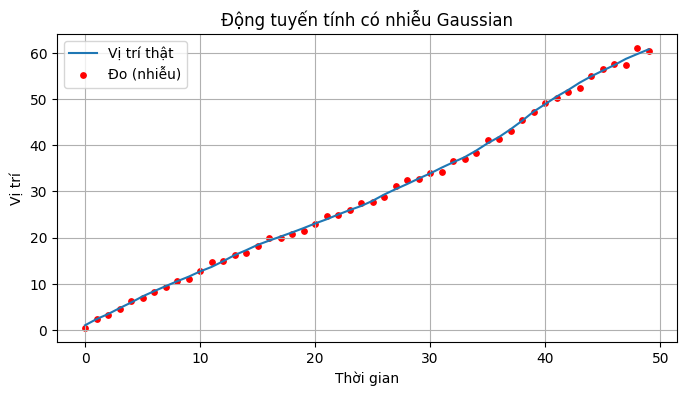

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Tham số hệ thống
# =========================
delta_t = 1.0        # bước thời gian
N = 50          # số bước mô phỏng

# Ma trận chuyển trạng thái (tuyến tính)
A = np.array([[1, delta_t],
              [0, 1]])

# Ma trận quan sát (chỉ đo vị trí)
H = np.array([[1, 0]])

# Hiệp phương sai nhiễu
Q = np.array([[0.01, 0],
              [0, 0.01]])   # nhiễu quá trình
R = np.array([[0.25]])      # nhiễu đo

# =========================
# Khởi tạo
# =========================
x = np.array([[0.0],   # vị trí ban đầu
              [1.0]])  # vận tốc ban đầu

true_states = []
measurements = []

# =========================
# Mô phỏng hệ động
# =========================
for k in range(N):
    # Nhiễu Gaussian
    w = np.random.multivariate_normal(mean=[0, 0], cov=Q).reshape(2, 1)
    v = np.random.normal(0, np.sqrt(R[0, 0]), size=(1, 1))

    # Phương trình trạng thái
    # Trạng thái mới là tổ hợp tuyến tính của trạng thái cũ và nhiễu quá trình
    x = A @ x + w

    # Phương trình đo
    # Đo là tổ hợp tuyến tính của trạng thái hiện tại và nhiễu đo
    z = H @ x + v

    true_states.append(x.copy())
    measurements.append(z.item())

# =========================
# Vẽ kết quả
# =========================
positions = [s[0, 0] for s in true_states]

plt.figure(figsize=(8, 4))
plt.plot(positions, label="Vị trí thật")
plt.scatter(range(N), measurements, color="red", s=15, label="Đo (nhiễu)")
plt.xlabel("Thời gian")
plt.ylabel("Vị trí")
plt.legend()
plt.title("Động tuyến tính có nhiễu Gaussian")
plt.grid()
plt.show()


# B. Kalman Filter
**Kalman Filter (KF)** là một thuật toán ước lượng trạng thái cho **hệ động tuyến tính có nhiễu Gaussian** - linear dynamical system with Gaussian noise.

**Mục tiêu:** ước lượng trạng thái thật của hệ thống mà ta không quan sát trực tiếp được.

Ví dụ:

* Theo dõi vị trí – vận tốc của xe

* Ước lượng trạng thái robot

* Lọc nhiễu tín hiệu cảm biến (GPS, IMU)





## 1. Ý tưởng cốt lõi
### 1.1. Dự đoán (Predict)
Dùng mô hình động để dự đoán trạng thái tiếp theos
$$
\hat{x}^-_k = A\hat{x}^-_{k-1}
$$
$$
P^-_k = AP^-_{k-1}A^T + Q
$$
* $\hat{x}^-_k$: ước lượng trước khi đo
* $P^-_k$: động không chắc chắn

### 1.2. Cập nhật (Update)
Kết hợp đo giá trị thực tế để hiệu chuẩn dự đoán

**Kalman Gain**
$$
K_k = P^-_kH^T(HP^-_kH^T + R)^{-1}
$$
Kalman gain quyết định tin:
* Mô hình (Q nhỏ)
* Phép đo (R nhỏ)

**Cập nhật trạng thái**
$$
\hat{x}_k = \hat{x}^-_k + K_k(z_k-H\hat{x}^-_k)
$$

**Cập nhật sai số**
$$
P_k = (I - K_kH)P^-_k
$$

## 2. Ưu điểm và nhược điểm
### 2.1. **Ưu điểm**
* Tối ưu theo nghĩa least square
* Chạy online, realtime
* Tính toán nhanh (O(n^3))
* Phổ biến trong tracking & robotics

### 2.2. **Nhược điểm**
* Chỉ áp dụng tốt cho tuyến tính
* Giả thiết nhiễu Gaussian
* Nhạy với việc chọn Q và R



## 3. Các biến thể phổ biến
* Kalman Filter -- Tuyến tính
* Extend KF (EKF) -- Phi tuyến (xấp xỉ tuyến tính)
* Unscented KF (UKF) -- Phi tuyến, chính xác hơn EKF
* Particle Filter -- Phi Gaussian, phi tuyến mạnh




## 4. Ứng dụng thực tế
* Theo dõi vật thể (YOLO + Kalman trong tracking)
* SLAM (robot, xe tự hành)
* GPS / IMU fusion
* Radar, sonar
* Dự báo chuỗi thời gian

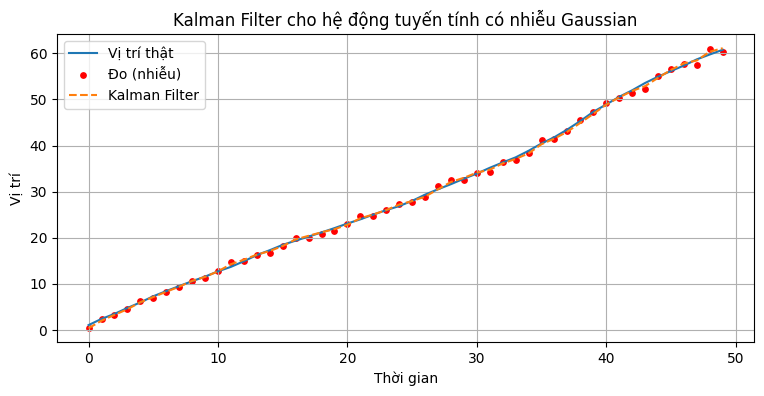

In [2]:
# =============================
# 3. Kalman Filter
# =============================
x_est = np.array([[0.0],
                  [0.0]])   # ước lượng ban đầu

P = np.eye(2)

est_states = []

for z in measurements:
    # ---- Prediction ----
    x_pred = A @ x_est # Dự đoán trạng thái tiếp theo
    P_pred = A @ P @ A.T + Q # Dự đoán hiệp phương sai

    # ---- Update ----
    S = H @ P_pred @ H.T + R # Độ đổi mới
    K = P_pred @ H.T @ np.linalg.inv(S) # Gain Kalman

    y = z - (H @ x_pred) # Sai số đo
    x_est = x_pred + K @ y # Cập nhật ước lượng trạng thái
    P = (np.eye(2) - K @ H) @ P_pred # Cập nhật hiệp phương sai

    est_states.append(x_est.copy())

# =============================
# 4. Vẽ kết quả
# =============================
true_pos = [x[0, 0] for x in true_states]
meas_pos = measurements
est_pos = [x[0, 0] for x in est_states]

plt.figure(figsize=(9, 4))
plt.plot(true_pos, label="Vị trí thật")
plt.scatter(range(N), meas_pos, color="red", s=15, label="Đo (nhiễu)")
plt.plot(est_pos, linestyle="--", label="Kalman Filter")
plt.xlabel("Thời gian")
plt.ylabel("Vị trí")
plt.legend()
plt.title("Kalman Filter cho hệ động tuyến tính có nhiễu Gaussian")
plt.grid()
plt.show()


# C. Ứng dụng KF trong Trackings

## 1. Tổng quan
Trong tracking, Kalman Filter (KF) không chỉ là “một thuật toán lọc”, mà đóng vai trò xương sống của hầu hết các hệ thống theo dõi hiện đại. Dưới đây là các ứng dụng cốt lõi, gắn trực tiếp với thực tế (CV, robotics, radar…).



## 1. Tổng quan
Trong tracking, Kalman Filter (KF) không chỉ là “một thuật toán lọc”, mà đóng vai trò xương sống của hầu hết các hệ thống theo dõi hiện đại. Dưới đây là các ứng dụng cốt lõi, gắn trực tiếp với thực tế (CV, robotics, radar…).

## 2. Ứng dụng thực tế

### 2.1. Dự đoán vị trí đối tượng (Prediction)
Problem:
* Detector chỉ cho kết quả tại frame hiện tại
* Frame tiếp theo đối tượng chưa được phát hiện hoặc bị che

Solution:
* Dự đoán vị trí tiếp theo dựa trên động học

Application:
* Tracking người/xe
* Theo dõi vật thể bị che khuất (occlusion)

In [3]:
print ("Kalman Filter initialized.")
dt = 1.0

A = np.array([[1, 0, dt, 0],
              [0, 1, 0, dt],
              [0, 0, 1,  0],
              [0, 0, 0,  1]])

H = np.array([[1, 0, 0, 0],
              [0, 1, 0, 0]])

Q = np.eye(4) * 0.01
R = np.eye(2) * 1.0

x = np.zeros((4, 1))   # state
P = np.eye(4)
I = np.eye(4)

Kalman Filter initialized.


In [4]:
# Predict
x = A @ x
P = A @ P @ A.T + Q

predicted_position = x[:2]

print("Predicted Position:\n", predicted_position)


Predicted Position:
 [[0.]
 [0.]]


### 2.2. Làm mượt quỹ đạo (Trajectory smoothing)
Problem:
* Detection rung, nhảy
* Bounding box không ổn định

Solution:
* Kết hợp mô hình chuyển động + đo
* Giảm nhiễu Gaussian

Application:
* Stabilize bounding box
* Làm mượt GPS/IMU

In [5]:
z = np.array([[1.0],
              [1.0]])

# Innovation
y = z - H @ x
S = H @ P @ H.T + R
K = P @ H.T @ np.linalg.inv(S)

# Update
x = x + K @ y
P = (I - K @ H) @ P
print("Updated State:\n", x)


Updated State:
 [[0.66777409]
 [0.66777409]
 [0.33222591]
 [0.33222591]]


### 2.3. Xử lý mất detection (Occlusion handling)
Problem:
* Object bị che vài frame
* Detector không trả kết quả

Solution:
* Chỉ predict, không update
* Giữ track “sống”

Application:
* Crowd tracking
* Giao thông, camera an ninh

In [6]:
# No update step
x = A @ x
P = A @ P @ A.T + Q
print("Predicted Position without Update:\n", x[:2])

Predicted Position without Update:
 [[1.]
 [1.]]


### 2.4. Data Association (Gán detection ↔ track)
Problem:
* Nhiều detection, nhiều track
* Ai thuộc về ai?

Solution:
* Dự đoán vùng khả dĩ (gating)
* Tính Mahalanobis distance
$$
d^2 = (x - H\hat{x}^-)^TS^{-1}(z-H\hat{x}^-)
$$

Application:
* SORT / DeepSORT
* Radar & lidar tracking

In [7]:

y = z - H @ x
S = H @ P @ H.T + R

d2 = y.T @ np.linalg.inv(S) @ y  # Mahalanobis distance

if d2 < 9.21:   # chi-square threshold (95%, df=2)
    print("Detection hợp lệ")
else:
    print("Detection bị loại")


Detection hợp lệ


### 2.5. Ước lượng vận tốc & trạng thái ẩn
Problem:
* Detector không đo vận tốc
* Nhưng ta cần vận tốc để dự đoán

Solution:
* Ước lượng state ẩn

Application:
* Ước lượng vận tốc xe
* Theo dõi hướng chuyển động

In [8]:
vx, vy = x[2, 0], x[3, 0]
speed = np.sqrt(vx**2 + vy**2)
print("Estimated Speed: {:.2f} units/time".format(speed))

Estimated Speed: 0.47 units/time


### 2.6. Track Management (sinh – xoá track)
Support:
* Confidence qua hiệp phương sai $P$
* Nếu $P$ quá lớn → track không tin cậy

Application:
* Tạo track mới
* Xoá track cũ

In [9]:
position_uncertainty = np.trace(P[:2, :2])

if position_uncertainty > 50:
    print("Xóa track")
# =============================


### 2.7. Tăng tốc hệ thống tracking
Optimize:
* Công thức đóng
* Độ phức tạp thấp

Application:
* Autonomous driving
* UAV, robotics

# C. SORT - Simple Online Realtime ObjectsTrackings






## 1. Giới thiệu
SORT là một thuật toán thuộc dạng Tracking-by-detection (hay Detection based Tracking). Đặc điểm của lớp thuật toán Tracking-by-dectection là tách riêng các object detection và tìm cách để tối ưu cho từng detection.  

Khung xử lí bao gồm có 3 phần:
* Detect: Nhận diện đối tượng trong frame
* Predict: Dự đoán vị trí của đối tượng đó trong frame tiếp theo
* Associate: Liên kết các vị trí detected của đối tượng đó để gán id





## 2. Giải thuật Hungary - Tối ưu hoá ánh xạ

Hungarian Algorithm giải bài toán **gán tối ưu 1–1 giữa hai tập sao cho tổng chi phí nhỏ nhất**. Trong toán học gọi là **Assignment Problem** (Bài toán phân công). Quan trọng hơn, giải thuật Hungarian là cầu nối giữa detection và KF trong nhiều bài toán trackings.

![Hungarian Algorithm](https://ds055uzetaobb.cloudfront.net/brioche/uploads/LviKNwDdBm-matching.png?width=1200)

Reference:
The Hungarian method for the assignment problem: https://web.eecs.umich.edu/~pettie/matching/Kuhn-hungarian-assignment.pdf

Hungarian Maximum Matching Algorithm: https://brilliant.org/wiki/hungarian-matching/

In [10]:
def find_uncovered_zero(cost, row_covered, col_covered):
    for i in range(cost.shape[0]):
        if row_covered[i]:
            continue
        for j in range(cost.shape[1]):
            if cost[i, j] == 0 and not col_covered[j]:
                return i, j
    return None

In [11]:
def adjust_matrix(cost, row_covered, col_covered):
    uncovered = cost[~row_covered][:, ~col_covered]
    min_val = uncovered.min()

    cost[~row_covered] -= min_val
    cost[:, col_covered] += min_val


In [12]:
def augment_path(starred, primed, start):
    path = [start]
    while True:
        row = path[-1][0]
        col = path[-1][1]

        star_row = np.where(starred[:, col])[0]
        if len(star_row) == 0:
            break
        path.append((star_row[0], col))

        prime_col = np.where(primed[row])[0][0]
        path.append((row, prime_col))

    for r, c in path:
        starred[r, c] = not starred[r, c]


In [13]:
import numpy as np
def linear_sum_assignment_numpy(cost):
    cost = cost.copy()
    n, m = cost.shape
    assert n <= m, "Hungarian implementation assumes rows <= cols"

    # Step 1: Row reduction
    cost -= cost.min(axis=1, keepdims=True)

    # Step 2: Column reduction
    cost -= cost.min(axis=0, keepdims=True)

    # Masks
    starred = np.zeros_like(cost, dtype=bool)
    primed = np.zeros_like(cost, dtype=bool)
    row_covered = np.zeros(n, dtype=bool)
    col_covered = np.zeros(m, dtype=bool)

    # Step 3: Star zeros
    for i in range(n):
        for j in range(m):
            if cost[i, j] == 0 and not row_covered[i] and not col_covered[j]:
                starred[i, j] = True
                row_covered[i] = True
                col_covered[j] = True

    row_covered[:] = False
    col_covered[:] = False

    # Main loop
    while True:
        # Cover columns with starred zeros
        col_covered[:] = starred.any(axis=0)

        if col_covered.sum() == n:
            break

        while True:
            # Step 4: Find uncovered zero
            zero = find_uncovered_zero(cost, row_covered, col_covered)
            if zero is None:
                # Step 6: Adjust matrix
                adjust_matrix(cost, row_covered, col_covered)
            else:
                i, j = zero
                primed[i, j] = True
                star_col = np.where(starred[i])[0]
                if len(star_col) == 0:
                    # Step 5: Augment path
                    augment_path(starred, primed, (i, j))
                    primed[:] = False
                    row_covered[:] = False
                    col_covered[:] = False
                    break
                else:
                    row_covered[i] = True
                    col_covered[star_col[0]] = False

    rows, cols = np.where(starred)
    return rows, cols


In [14]:
cost = np.array([
    [0.2, 0.8, 0.6],
    [0.7, 0.3, 0.4],
    [0.9, 0.5, 0.1]
])

r, c = linear_sum_assignment_numpy(cost)

for i, j in zip(r, c):
    print(f"Row {i} -> Col {j}, cost = {cost[i,j]}")


Row 0 -> Col 0, cost = 0.2
Row 1 -> Col 1, cost = 0.3
Row 2 -> Col 2, cost = 0.1


In [15]:
import numpy as np
from scipy.optimize import linear_sum_assignment

# Giả sử có 3 track và 3 detection
cost_matrix = np.array([
    [0.2, 0.8, 0.6],
    [0.7, 0.3, 0.4],
    [0.9, 0.5, 0.1]
])

row_ind, col_ind = linear_sum_assignment(cost_matrix)

print("Matches:")
for r, c in zip(row_ind, col_ind):
    print(f"Track {r} -> Detection {c}, cost = {cost_matrix[r, c]}")


Matches:
Track 0 -> Detection 0, cost = 0.2
Track 1 -> Detection 1, cost = 0.3
Track 2 -> Detection 2, cost = 0.1


## 3. Flowchat





In [16]:
import numpy as np
from filterpy.kalman import KalmanFilter
from scipy.optimize import linear_sum_assignment

def iou(bb_test, bb_gt):
    xx1 = np.maximum(bb_test[0], bb_gt[0])
    yy1 = np.maximum(bb_test[1], bb_gt[1])
    xx2 = np.minimum(bb_test[2], bb_gt[2])
    yy2 = np.minimum(bb_test[3], bb_gt[3])
    w = np.maximum(0., xx2 - xx1)
    h = np.maximum(0., yy2 - yy1)
    wh = w * h
    return wh / (
        (bb_test[2] - bb_test[0]) * (bb_test[3] - bb_test[1]) +
        (bb_gt[2] - bb_gt[0]) * (bb_gt[3] - bb_gt[1]) - wh
    )

class KalmanBoxTracker:
    count = 0

    def __init__(self, bbox):
        self.kf = KalmanFilter(dim_x=7, dim_z=4)
        self.kf.F = np.eye(7)
        self.kf.H = np.eye(4, 7)

        self.kf.x[:4] = bbox.reshape((4, 1))
        self.id = KalmanBoxTracker.count
        KalmanBoxTracker.count += 1
        self.time_since_update = 0

    def predict(self):
        self.kf.predict()
        self.time_since_update += 1
        return self.kf.x[:4].reshape(-1)

    def update(self, bbox):
        self.time_since_update = 0
        self.kf.update(bbox.reshape((4, 1)))

class Sort:
    def __init__(self, iou_threshold=0.3):
        self.trackers = []
        self.iou_threshold = iou_threshold

    def update(self, detections):
        predictions = np.array([t.predict() for t in self.trackers])

        matches = []
        if len(predictions) and len(detections):
            iou_matrix = np.zeros((len(predictions), len(detections)))
            for t, trk in enumerate(predictions):
                for d, det in enumerate(detections):
                    iou_matrix[t, d] = iou(trk, det)

            t_idx, d_idx = linear_sum_assignment(-iou_matrix)
            matches = [
                (t, d) for t, d in zip(t_idx, d_idx)
                if iou_matrix[t, d] > self.iou_threshold
            ]

        matched_t = set()
        for t, d in matches:
            self.trackers[t].update(detections[d])
            matched_t.add(t)

        for i, det in enumerate(detections):
            if i not in [d for _, d in matches]:
                self.trackers.append(KalmanBoxTracker(det))

        results = []
        for t in self.trackers:
            if t.time_since_update == 0:
                bbox = t.kf.x[:4].reshape(-1)
                results.append(np.concatenate([bbox, [t.id]]))

        return np.array(results)


In [17]:
import numpy as np

tracker = Sort()

# giả lập detections cho 3 frame
frames = [
    np.array([[100, 100, 200, 200]]),
    np.array([[105, 105, 205, 205]]),
    np.array([[110, 110, 210, 210]])
]

for frame_id, dets in enumerate(frames):
    tracks = tracker.update(dets)
    print(f"Frame {frame_id}:")
    for t in tracks:
        print(f"ID {int(t[4])}, BBox {t[:4]}")


Frame 0:
ID 0, BBox [100. 100. 200. 200.]
Frame 1:
ID 0, BBox [103.33333333 103.33333333 203.33333333 203.33333333]
Frame 2:
ID 0, BBox [107.5 107.5 207.5 207.5]
